In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Load Data

In [ ]:
# Load your data
train_df = pd.read_csv('../data/classification/classification-train.csv')

# Data Cleaning

In [3]:
train_df['Timestamp_Local'] = pd.to_datetime(train_df['Timestamp_Local'])
train_df = train_df.sort_values(['Site', 'Timestamp_Local']).reset_index(drop=True)

### Target value Distribution

Demand Response Flag Distribution:
Demand_Response_Flag
-1      2262
 0    102011
 1       847
Name: count, dtype: int64

Percentages:
Demand_Response_Flag
-1     2.151826
 0    97.042428
 1     0.805746
Name: proportion, dtype: float64


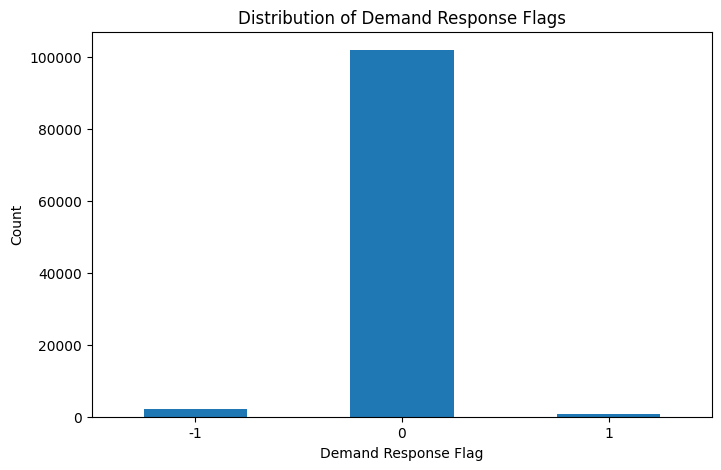

In [4]:
print("Demand Response Flag Distribution:")
print(train_df['Demand_Response_Flag'].value_counts().sort_index())
print("\nPercentages:")
print(train_df['Demand_Response_Flag'].value_counts(normalize=True).sort_index() * 100)

# Visualize
plt.figure(figsize=(8, 5))
train_df['Demand_Response_Flag'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Demand Response Flags')
plt.xlabel('Demand Response Flag')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Feature Engineering

Future improvements: cyclical encoding, more lags, interaction features, weather-normalized power

Note: Removed site_encoded to enable generalization to unseen sites.
Model will learn site-agnostic patterns based on power behavior and weather

In [5]:
# Basic temporal features
train_df['hour'] = train_df['Timestamp_Local'].dt.hour
train_df['day_of_week'] = train_df['Timestamp_Local'].dt.dayofweek
train_df['month'] = train_df['Timestamp_Local'].dt.month  # Capture seasonality
train_df['is_weekend'] = (train_df['day_of_week'] >= 5).astype(int)

# Simple rolling statistics (per site) - captures "normal" behavior
for site in train_df['Site'].unique():
    mask = train_df['Site'] == site
    # Rolling mean of power (1 hour = 4 timesteps)
    train_df.loc[mask, 'power_rolling_mean'] = train_df.loc[mask, 'Building_Power_kW'].rolling(window=4, min_periods=1).mean()
    # Longer rolling mean (3 hours) for better baseline
    train_df.loc[mask, 'power_rolling_mean_3h'] = train_df.loc[mask, 'Building_Power_kW'].rolling(window=12, min_periods=1).mean()
    # Power lag
    train_df.loc[mask, 'power_lag_1'] = train_df.loc[mask, 'Building_Power_kW'].shift(1)

# Power deviation from rolling mean (key feature for DR detection!)
train_df['power_deviation_1h'] = train_df['Building_Power_kW'] - train_df['power_rolling_mean']
train_df['power_deviation_3h'] = train_df['Building_Power_kW'] - train_df['power_rolling_mean_3h']

# Percentage change (normalized, helps with different building sizes)
train_df['power_pct_change_1h'] = train_df['power_deviation_1h'] / (train_df['power_rolling_mean'] + 1e-6)
train_df['power_pct_change_3h'] = train_df['power_deviation_3h'] / (train_df['power_rolling_mean_3h'] + 1e-6)

# Fill NaN from rolling/lag
train_df = train_df.fillna(method='bfill')

## Training

In [6]:
# Define features
feature_cols = [
    'Dry_Bulb_Temperature_C',
    'Global_Horizontal_Radiation_W/m2', 
    'Building_Power_kW',
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'power_rolling_mean',
    'power_rolling_mean_3h',
    'power_lag_1',
    'power_deviation_1h',
    'power_deviation_3h',
    'power_pct_change_1h',  # Normalized deviation - important for different building sizes
    'power_pct_change_3h'
]

X = train_df[feature_cols]
y = train_df['Demand_Response_Flag']

# Map labels to 0, 1, 2 for LightGBM
label_mapping = {-1: 0, 0: 1, 1: 2}
inverse_label_mapping = {0: -1, 1: 0, 2: 1}
y_mapped = y.map(label_mapping)

print(f"Features: {len(feature_cols)}")
print(f"Training samples: {len(X)}")

Features: 14
Training samples: 105120


### Data Split

Site-based split: Train on siteA + siteB, Validate on siteC
This tests generalization to unseen sites (similar to test scenario)

In [7]:
train_sites = ['siteA', 'siteB']
val_sites = ['siteC']

train_mask = train_df['Site'].isin(train_sites)
val_mask = train_df['Site'].isin(val_sites)

X_train = X[train_mask]
X_val = X[val_mask]
y_train = y_mapped[train_mask]
y_val = y_mapped[val_mask]

print(f"Train sites: {train_sites}")
print(f"Validation sites: {val_sites}")
print(f"Train: {len(X_train)}, Validation: {len(X_val)}")
print(f"\nTrain DR distribution:")
print(y_train.value_counts().sort_index())
print(f"\nVal DR distribution:")
print(y_val.value_counts().sort_index())

Train sites: ['siteA', 'siteB']
Validation sites: ['siteC']
Train: 70080, Validation: 35040

Train DR distribution:
Demand_Response_Flag
0     1307
1    68200
2      573
Name: count, dtype: int64

Val DR distribution:
Demand_Response_Flag
0      955
1    33811
2      274
Name: count, dtype: int64


### Training Run

In [10]:
# Train LightGBM with class weights for severe imbalance
model = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=RANDOM_SEED,
    class_weight='balanced',  # Handles 97% vs 3% imbalance
    verbose=-1
)

print("Training model...")
model.fit(X_train, y_train)
print("Done!")

Training model...
Done!


### Evaluate on Validation Set

In [19]:
# Predict
y_val_pred = model.predict(X_val)

# Map back to original labels - CONVERT TO NUMPY ARRAYS
y_val_original = y_val.map(inverse_label_mapping).values  # .values is key!
y_val_pred_original = pd.Series(y_val_pred).map(inverse_label_mapping).values  # .values is key!

# Detailed classification report
print("Classification Report:")
print(classification_report(y_val_original, y_val_pred_original, 
                          target_names=['DR: -1', 'DR: 0', 'DR: 1'],
                          zero_division=0))

# Calculate Geometric Mean Score (competition metric)
# Binary: event (DR flag != 0) vs no event (DR flag == 0)
y_true_binary = (y_val_original != 0).astype(int)
y_pred_binary = (y_val_pred_original != 0).astype(int)

TP = np.sum((y_true_binary == 1) & (y_pred_binary == 1))
TN = np.sum((y_true_binary == 0) & (y_pred_binary == 0))
FP = np.sum((y_true_binary == 0) & (y_pred_binary == 1))
FN = np.sum((y_true_binary == 1) & (y_pred_binary == 0))

print(f"\nConfusion Matrix (Binary):")
print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
TNR = TN / (TN + FP) if (TN + FP) > 0 else 0
gm_score = np.sqrt(TPR * TNR)

print(f"\nGeometric Mean Score: {gm_score:.4f}")
print(f"TPR (Sensitivity): {TPR:.4f}")
print(f"TNR (Specificity): {TNR:.4f}")

print(f"\nPrediction distribution:")
unique, counts = np.unique(y_val_pred_original, return_counts=True)
for val, count in zip(unique, counts):
    print(f"  {val}: {count}")

Classification Report:
              precision    recall  f1-score   support

      DR: -1       0.46      0.09      0.15       955
       DR: 0       0.98      0.82      0.89     33811
       DR: 1       0.03      0.66      0.05       274

    accuracy                           0.80     35040
   macro avg       0.49      0.52      0.37     35040
weighted avg       0.96      0.80      0.87     35040


Confusion Matrix (Binary):
TP: 788, TN: 27645, FP: 6166, FN: 441

Geometric Mean Score: 0.7240
TPR (Sensitivity): 0.6412
TNR (Specificity): 0.8176

Prediction distribution:
  -1: 186
  0: 28086
  1: 6768


## Submission

### Load an prepare Test Data

In [14]:
# Load test data (different sites than training!)
# test_df = pd.read_csv('../data/classification/classification-test.csv')
test_df = pd.read_csv('../data/regression/regression-test.csv')

test_df['Timestamp_Local'] = pd.to_datetime(test_df['Timestamp_Local'])
test_df = test_df.sort_values(['Site', 'Timestamp_Local']).reset_index(drop=True)

print(f"Test data shape: {test_df.shape}")
print(f"Test sites: {test_df['Site'].unique()}")

# Apply same feature engineering
test_df['hour'] = test_df['Timestamp_Local'].dt.hour
test_df['day_of_week'] = test_df['Timestamp_Local'].dt.dayofweek
test_df['month'] = test_df['Timestamp_Local'].dt.month
test_df['is_weekend'] = (test_df['day_of_week'] >= 5).astype(int)

for site in test_df['Site'].unique():
    mask = test_df['Site'] == site
    test_df.loc[mask, 'power_rolling_mean'] = test_df.loc[mask, 'Building_Power_kW'].rolling(window=4, min_periods=1).mean()
    test_df.loc[mask, 'power_rolling_mean_3h'] = test_df.loc[mask, 'Building_Power_kW'].rolling(window=12, min_periods=1).mean()
    test_df.loc[mask, 'power_lag_1'] = test_df.loc[mask, 'Building_Power_kW'].shift(1)

test_df['power_deviation_1h'] = test_df['Building_Power_kW'] - test_df['power_rolling_mean']
test_df['power_deviation_3h'] = test_df['Building_Power_kW'] - test_df['power_rolling_mean_3h']
test_df['power_pct_change_1h'] = test_df['power_deviation_1h'] / (test_df['power_rolling_mean'] + 1e-6)
test_df['power_pct_change_3h'] = test_df['power_deviation_3h'] / (test_df['power_rolling_mean_3h'] + 1e-6)

test_df = test_df.fillna(method='bfill')

print("Test features created!")

Test data shape: (105120, 6)
Test sites: ['siteD' 'siteE' 'siteF']
Test features created!


### Predict Submission

In [17]:
# Predict on test set
X_test = test_df[feature_cols]
y_test_pred = model.predict(X_test)
y_test_pred_original = pd.Series(y_test_pred).map(inverse_label_mapping)

# Create submission
submission = pd.DataFrame({
    'Site': test_df['Site'],
    'Timestamp_Local': test_df['Timestamp_Local'],
    'Dry_Bulb_Temperature_C': test_df['Dry_Bulb_Temperature_C'],
    'Global_Horizontal_Radiation_W/m2': test_df['Global_Horizontal_Radiation_W/m2'],
    'Building_Power_kW': test_df['Building_Power_kW'],
    'Demand_Response_Flag': y_test_pred_original
})

submission.to_csv('../outputs/baseline-classification-competition-submission.csv', index=False)

print("Submission created!")
print(f"\nPrediction distribution:")
print(submission['Demand_Response_Flag'].value_counts().sort_index())
print("\nFirst few predictions:")
submission.head(10)

Submission created!

Prediction distribution:
Demand_Response_Flag
-1     2595
 0    93740
 1     8785
Name: count, dtype: int64

First few predictions:


,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag
0,siteD,2020-01-01 00:00:00,24.70,0,4.8,0
1,siteD,2020-01-01 00:15:00,24.61,0,4.8,0
2,siteD,2020-01-01 00:30:00,24.53,0,4.8,0
3,siteD,2020-01-01 00:45:00,24.45,0,4.8,0
4,siteD,2020-01-01 01:00:00,24.36,0,4.8,0
5,siteD,2020-01-01 01:15:00,24.28,0,4.8,0
6,siteD,2020-01-01 01:30:00,24.20,0,4.8,0
7,siteD,2020-01-01 01:45:00,24.11,0,4.8,0
8,siteD,2020-01-01 02:00:00,24.03,0,4.8,0
9,siteD,2020-01-01 02:15:00,23.95,0,4.8,0
